## CIFAR 10 image classification using CNN (Baseline)

## Model
Conv → ReLU → Pool → Conv → ReLU → Pool → Conv → ReLU → Pool → FC → ReLU → FC

## Training
Adam (lr=0.001), 10 epochs, batch size 32

## Result
Accuracy: ~69.6%

## Observations
- LR was the most critical factor
- More epochs → better convergence
- ReLU improved performance
- Normalization gave stable gains


In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

### Transforms: Normalization & ToTensor()

In [4]:
# transform = transforms.ToTensor()
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,0.5,0.5), (0.5,0.5,0.5))
])

### Data Preparation

In [3]:
train_data = datasets.CIFAR10('./data', train = True, transform= transform, download = True)
test_data = datasets.CIFAR10('./data', train= False, transform = transform, download = True)

train_loader = DataLoader(train_data, batch_size = 32, shuffle =True)
test_loader = DataLoader(test_data, batch_size = 32, shuffle = False)

images , labels = next(iter(train_loader))
print(images.shape, labels.shape)

torch.Size([32, 3, 32, 32]) torch.Size([32])


### Visualizing the data

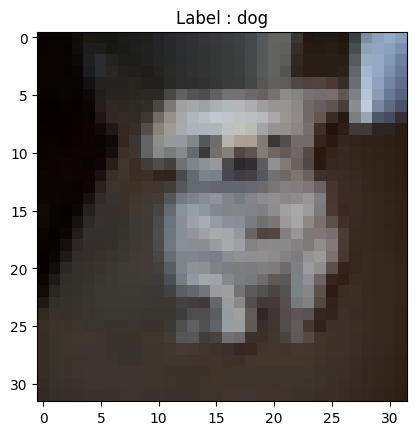

In [8]:
import matplotlib.pyplot as plt
img = images[0].permute(1, 2,0)
img = img*0.5+0.5
plt.imshow(img)
# plt.imshow(images[0].squeeze().reshape(32,32,3))
plt.title(f"Label : {train_data.classes[labels[0].item()]}")
plt.show()

### Model

In [9]:
from torch.nn.modules.linear import Linear
from torch.nn.modules.flatten import Flatten
model = nn.Sequential(
    nn.Conv2d(3,16, 3),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(16, 32, 3),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Conv2d(32, 64, 3),
    nn.ReLU(),
    nn.MaxPool2d(2),

    nn.Flatten(),
    nn.Linear(64*2*2, 128),
    nn.ReLU(),
    nn.Linear(128, 10)
)

print(model)

Sequential(
  (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1))
  (1): ReLU()
  (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (3): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1))
  (4): ReLU()
  (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (6): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1))
  (7): ReLU()
  (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (9): Flatten(start_dim=1, end_dim=-1)
  (10): Linear(in_features=256, out_features=128, bias=True)
  (11): ReLU()
  (12): Linear(in_features=128, out_features=10, bias=True)
)


### Optional : verify the shapes as the input passes through the model

In [26]:
images, labels = next(iter(train_loader))
x = images
print(x.shape)
for layer in model:
  x = layer(x)
  print(x.shape)

torch.Size([32, 3, 32, 32])
torch.Size([32, 16, 30, 30])
torch.Size([32, 16, 30, 30])
torch.Size([32, 16, 15, 15])
torch.Size([32, 32, 13, 13])
torch.Size([32, 32, 13, 13])
torch.Size([32, 32, 6, 6])
torch.Size([32, 64, 4, 4])
torch.Size([32, 64, 4, 4])
torch.Size([32, 64, 2, 2])
torch.Size([32, 256])
torch.Size([32, 128])
torch.Size([32, 128])
torch.Size([32, 10])


### Training

In [28]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr = 0.001)

for epoch in range(10):
  model.train()
  total_loss = 0

  for images, labels in train_loader:
    outputs= model(images)
    loss = loss_fn(outputs, labels)

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()
    total_loss += loss

  avg_loss = total_loss/len(train_loader)
  print(f"Epoch {epoch+1} done, Loss= {avg_loss.item()}")

print("Training completed successfully")

Epoch 1 done, Loss= 1.5526554584503174
Epoch 2 done, Loss= 1.1946569681167603
Epoch 3 done, Loss= 1.0443249940872192
Epoch 4 done, Loss= 0.9380717873573303
Epoch 5 done, Loss= 0.8594197630882263
Epoch 6 done, Loss= 0.7990362644195557
Epoch 7 done, Loss= 0.7536265254020691
Epoch 8 done, Loss= 0.7108469009399414
Epoch 9 done, Loss= 0.6752592921257019
Epoch 10 done, Loss= 0.638834536075592
Training completed successfully


### Inference

In [29]:
###### inference #########

correct = 0
total = 0

model.eval()
for images, labels in test_loader:
  outputs = model(images)
  _, preds = torch.max(outputs, dim = 1)
  correct += (preds == labels).sum().item()
  total += len(labels)

print("correct: ", correct)
print("total: ", total)
print(f"Accuracy is {(correct/total)*100} %")

correct:  6965
total:  10000
Accuracy is 69.65 %
